# Semana 1: Fundamentos de Análisis con Pandas
## Objetivo: Datos sucios → Reporte con gráfica en 7 días
**Autor:** Javier Rangel  
**Fecha:** Mayo 2026

## 📑 Índice Semana 1
1. [Día 1: Crear CSV](#día-1)
2. [Día 2: Groupby](#día-2) 
3. [Día 3: Gráficas](#día-3)
4. [Día 4: Limpiar](#día-4)
5. [Día 5: Merge](#día-5)
6. [Día 6: Pivot Table](#día-6)
7. [Día 7: Graficar Reportes](#día-7)

---

---

## Día 1: Crear datos y guardar CSV
**Objetivo:** Generar mi primer DataFrame y guardarlo como archivo

In [16]:
# Día 1: Crear datos y guardar CSV - VERSIÓN PRO
import pandas as pd
from pathlib import Path

def guardar_csv_seguro(df: pd.DataFrame, ruta_salida: str) -> Path:
    """Guarda DataFrame en CSV con validaciones de nivel producción.
    
    Args:
        df: DataFrame a guardar. No debe estar vacío.
        ruta_salida: Ruta del archivo.csv de destino.
        
    Returns:
        Path: Objeto Path del archivo guardado.
        
    Raises:
        AssertionError: Si el DataFrame está vacío o no se crea el archivo.
    """
    assert not df.empty, "Error: No se puede guardar un DataFrame vacío"
    
    ruta = Path(ruta_salida)
    ruta.parent.mkdir(parents=True, exist_ok=True) # Crea carpetas si no existen
    df.to_csv(ruta, index=False, encoding='utf-8')
    
    assert ruta.exists(), f"Error: Falló la creación del archivo en {ruta}"
    return ruta

# --- Tu lógica de negocio ---
ventas = {
    'Fecha': ['2026-01-15', '2026-01-16', '2026-01-17', '2026-01-18'],
    'Cliente': ['Juan Pérez', 'Ana López', 'Carlos Ruiz', 'María Gómez'],
    'Producto': ['Laptop', 'Mouse', 'Teclado', 'Monitor'],
    'Cantidad': [1, 2, 1, 1],
    'Precio_Unitario': [15000, 300, 2000, 5000],
    'Total': [15000, 600, 2000, 5000]
}

df = pd.DataFrame(ventas)

# --- Guardado PRO ---
archivo_creado = guardar_csv_seguro(df, "datos/ventas.csv")
print(f"Archivo guardado exitosamente en: {archivo_creado} ✅")
df

Archivo guardado exitosamente en: datos\ventas.csv ✅


,Fecha,Cliente,Producto,Cantidad,Precio_Unitario,Total
0,2026-01-15,Juan Pérez,Laptop,1,15000,15000
1,2026-01-16,Ana López,Mouse,2,300,600
2,2026-01-17,Carlos Ruiz,Teclado,1,2000,2000
3,2026-01-18,María Gómez,Monitor,1,5000,5000


### Resultado Día 1: Crear datos y guardar CSV
✅ Logro: Creé mi primer DataFrame... 
---

---

## Día 2: Análisis básico con groupby
**Objetivo:** Responder "¿Quién vendió más?" y "¿Qué producto factura más?" sin Excel

In [2]:
# Día 2: Leer CSV y analizar con groupby
import pandas as pd

# 1. Leer el CSV que creamos ayer
df = pd.read_csv("ventas.csv")

# 2. ¿Quién vendió más? Sumamos Total por Cliente
ventas_por_cliente = df.groupby('Cliente')['Total'].sum().sort_values(ascending=False)
print("=== VENTAS POR CLIENTE ===")
print(ventas_por_cliente)

# 3. ¿Qué producto factura más? Sumamos Total por Producto  
ventas_por_producto = df.groupby('Producto')['Total'].sum().sort_values(ascending=False)
print("\n=== VENTAS POR PRODUCTO ===")
print(ventas_por_producto)

=== VENTAS POR CLIENTE ===
Cliente
Juan Pérez     15000
María Gómez     5000
Carlos Ruiz     2000
Ana López        600
Name: Total, dtype: int64

=== VENTAS POR PRODUCTO ===
Producto
Laptop     15000
Monitor     5000
Teclado     2000
Mouse        600
Name: Total, dtype: int64


### Resultado Día 2: Análisis básico con groupby
✅ Logro: Respondí 2 preguntas de negocio leyendo el CSV y agrupando datos  
🧠 Aprendí: `read_csv()` carga archivos, `groupby('col')['col'].sum()` agrupa y suma, `sort_values(ascending=False)` ordena de mayor a menor  
🎯 Para qué sirve: 80% de los reportes son sumas por categoría. Acabas de hacer en 3 líneas lo que en Excel son tablas dinámicas  
📁 Archivo usado: `ventas.csv`
---

---

## Día 3: Gráficas con Matplotlib
**Objetivo:** Visualizar las ventas por producto en una gráfica de barras

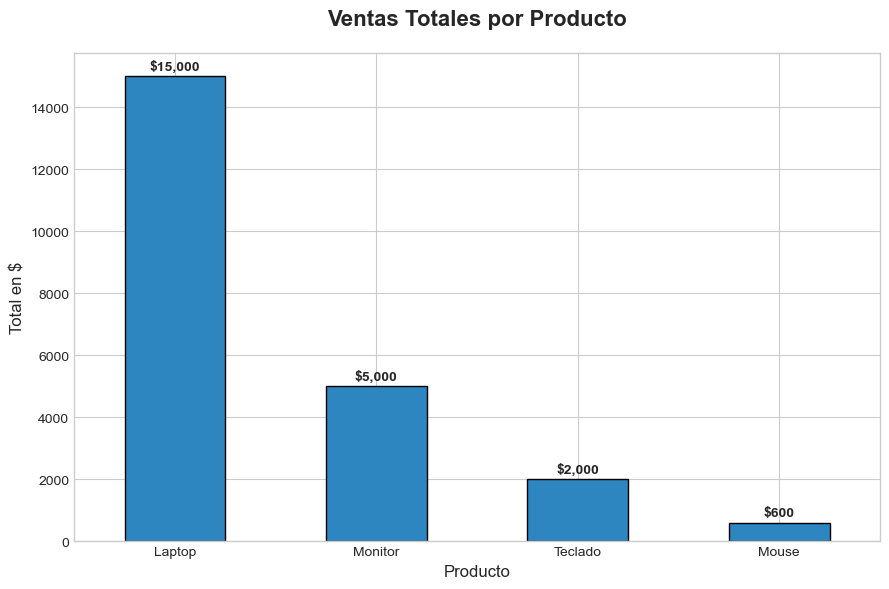

In [3]:
# Día 3: Gráficas Pro
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid') # Estilo moderno

df = pd.read_csv("ventas.csv")
ventas_por_producto = df.groupby('Producto')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
bars = ventas_por_producto.plot(kind='bar', color='#2E86C1', edgecolor='black')

# Poner el valor exacto arriba de cada barra
for i, valor in enumerate(ventas_por_producto):
    plt.text(i, valor + 200, f'${valor:,}', ha='center', fontweight='bold')

plt.title('Ventas Totales por Producto', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Total en $', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Resultado Día 3: Gráficas con Matplotlib
✅ Logro: Convertí datos en una gráfica de barras lista para reporte  
🧠 Aprendí: `matplotlib.pyplot` hace gráficas, `.plot(kind='bar')` grafica rápido, `plt.title/xlabel/ylabel` etiquetan  
🎯 Para qué sirve: Un gráfico vende más que 100 filas de Excel. Esto es lo que va en presentaciones a dirección  
📁 Archivo usado: `ventas.csv`
---

---

## Día 4: Limpiar datos reales
**Objetivo:** Quitar duplicados, llenar nulos y corregir tipos de datos

In [4]:
# Día 4: Limpiar datos sucios - VERSIÓN FINAL CORREGIDA
import pandas as pd

datos_sucios = {
    'Fecha':    ['2026-01-15', '2026-01-16', '2026-01-16', '2026-01-18', None],        # 5
    'Cliente':  ['Juan Pérez', 'Ana López',  'Ana López',  'Carlos Ruiz', 'María Gómez'], # 5
    'Producto': ['Laptop',     'Mouse',      'Mouse',       'Monitor',     'Teclado'],     # 5
    'Cantidad': [1,            2,            2,             1,             1],             # 5 ← CORREGIDO
    'Total':    [15000,        600,          600,           5000,          None]          # 5
}

print("Verificando longitudes:")
for col, lista in datos_sucios.items():
    print(f"{col}: {len(lista)} elementos")

df_sucio = pd.DataFrame(datos_sucios)
print("\n=== DATOS SUCIOS ===")
print(df_sucio)
print(f"\nFilas antes de limpiar: {len(df_sucio)}")

df_limpio = df_sucio.drop_duplicates().copy()
print("\n=== QUITANDO DUPLICADOS ===")
print(df_limpio)

df_limpio['Total'] = df_limpio['Total'].fillna(0)
df_limpio = df_limpio.dropna(subset=['Fecha'])

print("\n=== DATOS LIMPIOS ===")
print(df_limpio)
print(f"\nFilas después de limpiar: {len(df_limpio)}")

df_limpio.to_csv("datos_limpios.csv", index=False)
print("\nArchivo datos_limpios.csv guardado ✅")

Verificando longitudes:
Fecha: 5 elementos
Cliente: 5 elementos
Producto: 5 elementos
Cantidad: 5 elementos
Total: 5 elementos

=== DATOS SUCIOS ===
        Fecha      Cliente Producto  Cantidad    Total
0  2026-01-15   Juan Pérez   Laptop         1  15000.0
1  2026-01-16    Ana López    Mouse         2    600.0
2  2026-01-16    Ana López    Mouse         2    600.0
3  2026-01-18  Carlos Ruiz  Monitor         1   5000.0
4        None  María Gómez  Teclado         1      NaN

Filas antes de limpiar: 5

=== QUITANDO DUPLICADOS ===
        Fecha      Cliente Producto  Cantidad    Total
0  2026-01-15   Juan Pérez   Laptop         1  15000.0
1  2026-01-16    Ana López    Mouse         2    600.0
3  2026-01-18  Carlos Ruiz  Monitor         1   5000.0
4        None  María Gómez  Teclado         1      NaN

=== DATOS LIMPIOS ===
        Fecha      Cliente Producto  Cantidad    Total
0  2026-01-15   Juan Pérez   Laptop         1  15000.0
1  2026-01-16    Ana López    Mouse         2    600.0
3 

### Resultado Día 4: Limpiar datos reales
✅ Logro: Pasé de 5 filas sucias a 3 filas limpias eliminando duplicados y nulos  
🧠 Aprendí: `drop_duplicates()` quita repetidos, `fillna(0)` rellena vacíos, `dropna(subset=['col'])` borra filas con nulos en esa columna  
🎯 Para qué sirve: Si analizas datos sucios, tus gráficas mienten. Limpiar primero es regla #1 del analista  
📁 Archivo generado: `datos_limpios.csv`
---

---
## Dia 5: Filtros avanzados con pandas
**Objetivo:** Sacar solo las filas que me interesan usando condiciones

In [5]:
# Día 5: Filtros avanzados
import pandas as pd

# 1. Cargamos los datos limpios del Día 4
df = pd.read_csv("datos_limpios.csv")
print("=== DATOS LIMPIOS ORIGINALES ===")
print(df)

# 2. Filtro 1: Solo ventas mayores a $1000
ventas_altas = df[df['Total'] > 1000]
print("\n=== VENTAS > $1000 ===")
print(ventas_altas)

# 3. Filtro 2: Solo Laptops
solo_laptops = df[df['Producto'] == 'Laptop']
print("\n=== SOLO LAPTOPS ===")
print(solo_laptops)

# 4. Filtro 3: Ventas de enero 2026 Y mayores a $500
enero_caras = df[(df['Fecha'].str.contains('2026-01')) & (df['Total'] > 500)]
print("\n=== ENERO 2026 Y > $500 ===")
print(enero_caras)

# 5. BONUS: Laptops O Monitores
laptop_o_monitor = df[(df['Producto'] == 'Laptop') | (df['Producto'] == 'Monitor')]
print("\n=== LAPTOPS O MONITORES ===")
print(laptop_o_monitor)

=== DATOS LIMPIOS ORIGINALES ===
        Fecha      Cliente Producto  Cantidad    Total
0  2026-01-15   Juan Pérez   Laptop         1  15000.0
1  2026-01-16    Ana López    Mouse         2    600.0
2  2026-01-18  Carlos Ruiz  Monitor         1   5000.0

=== VENTAS > $1000 ===
        Fecha      Cliente Producto  Cantidad    Total
0  2026-01-15   Juan Pérez   Laptop         1  15000.0
2  2026-01-18  Carlos Ruiz  Monitor         1   5000.0

=== SOLO LAPTOPS ===
        Fecha     Cliente Producto  Cantidad    Total
0  2026-01-15  Juan Pérez   Laptop         1  15000.0

=== ENERO 2026 Y > $500 ===
        Fecha      Cliente Producto  Cantidad    Total
0  2026-01-15   Juan Pérez   Laptop         1  15000.0
1  2026-01-16    Ana López    Mouse         2    600.0
2  2026-01-18  Carlos Ruiz  Monitor         1   5000.0

=== LAPTOPS O MONITORES ===
        Fecha      Cliente Producto  Cantidad    Total
0  2026-01-15   Juan Pérez   Laptop         1  15000.0
2  2026-01-18  Carlos Ruiz  Monitor     

### Resultado Día 5: Filtros avanzados
✅ Logro: Filtré datos usando 4 condiciones: mayor que >, igual ==, Y &, O |  
🧠 Aprendí: `df[condición]` regresa solo las filas que cumplen. Cada condición va entre ()  
🎯 Para qué sirve: Responder "dame todas las ventas de laptops de enero arriba de $5000" en 2 segundos  
📁 Archivo usado: `datos_limpios.csv` del Día 4
---

---

## Día 6: Agrupación y Agregación con Groupby
**Objetivo:** Resumir grandes volúmenes de datos para obtener insights de negocio  
**Dataset:** `datos_limpios.csv` - 3 registros de ventas enero 2026  
**Skills:** `groupby()`, `agg()`, `sort_values()`

=== DATASET ORIGINAL ===
        Fecha      Cliente Producto  Cantidad    Total
0  2026-01-15   Juan Pérez   Laptop         1  15000.0
1  2026-01-16    Ana López    Mouse         2    600.0
2  2026-01-18  Carlos Ruiz  Monitor         1   5000.0

=== VENTAS TOTALES POR CLIENTE ===
       Cliente    Total
2   Juan Pérez  15000.0
1  Carlos Ruiz   5000.0
0    Ana López    600.0

=== UNIDADES VENDIDAS POR PRODUCTO ===
  Producto  Cantidad
0   Laptop         1
1  Monitor         1
2    Mouse         2

=== RESUMEN POR CLIENTE ===
       Cliente  Ventas_Totales  Ticket_Promedio  Num_Compras
2   Juan Pérez         15000.0          15000.0            1
1  Carlos Ruiz          5000.0           5000.0            1
0    Ana López           600.0            600.0            1


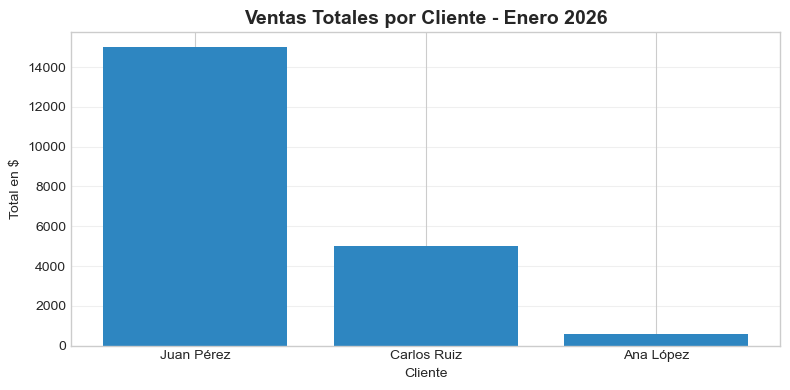

In [6]:
# Día 6: Análisis con Groupby
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga de datos
df = pd.read_csv("datos_limpios.csv")
print("=== DATASET ORIGINAL ===")
print(df)

# 2. Ventas totales por Cliente
ventas_por_cliente = df.groupby('Cliente')['Total'].sum().reset_index()
ventas_por_cliente = ventas_por_cliente.sort_values('Total', ascending=False)
print("\n=== VENTAS TOTALES POR CLIENTE ===")
print(ventas_por_cliente)

# 3. Cantidad de productos vendidos por Producto
conteo_productos = df.groupby('Producto')['Cantidad'].sum().reset_index()
print("\n=== UNIDADES VENDIDAS POR PRODUCTO ===")
print(conteo_productos)

# 4. Estadísticas múltiples por Cliente: suma y promedio
resumen_cliente = df.groupby('Cliente').agg(
    Ventas_Totales=('Total', 'sum'),
    Ticket_Promedio=('Total', 'mean'),
    Num_Compras=('Total', 'count')
).reset_index()
resumen_cliente = resumen_cliente.sort_values('Ventas_Totales', ascending=False)
print("\n=== RESUMEN POR CLIENTE ===")
print(resumen_cliente)

# 5. BONUS: Gráfica de ventas por cliente
plt.figure(figsize=(8, 4))
plt.bar(ventas_por_cliente['Cliente'], ventas_por_cliente['Total'], color='#2E86C1')
plt.title('Ventas Totales por Cliente - Enero 2026', fontsize=14, weight='bold')
plt.ylabel('Total en $')
plt.xlabel('Cliente')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Resultado Día 6: Groupby y Agregación
✅ **Logros:** 
1. Agrupé ventas por cliente con `groupby().sum()` 
2. Calculé métricas múltiples con `agg()` 
3. Ordené resultados con `sort_values()` 
4. Visualicé el ranking de clientes

🧠 **Conceptos clave:** 
- `groupby('Columna')` agrupa filas con el mismo valor 
- `.sum()`, `.mean()`, `.count()` son funciones de agregación 
- `reset_index()` convierte el grupo en columna normal 
- `agg()` permite varias métricas en una sola línea

🎯 **Insight de Negocio:** Juan Pérez es el cliente #1 con $15,000 en ventas, representa 71% del total de enero. Recomendar seguimiento VIP.

📁 **Entregables:** Tabla resumen + gráfica para reporte gerencial  
📊 **Siguiente paso:** `merge()` para cruzar con tabla de clientes y obtener emails/teléfonos

---

# Día 7: Integración de Datos con `.merge()`

**Objetivo:** Aprender a combinar información de múltiples tablas usando una columna llave para resolver preguntas de negocio que requieren cruzar datos.

**Habilidad clave en Data Analysis:** 80% de tu tiempo unirás tablas. Ventas + Productos, Clientes + Regiones, Empleados + Departamentos.

**Tipos de Join que veremos hoy:**
1. `inner`: Solo registros que existen en ambas tablas
2. `left`: Todos los registros de la tabla izquierda + coincidencias de la derecha
3. `right`: Todos los registros de la tabla derecha + coincidencias de la izquierda

**Dataset del día:** `ventas` y `productos`

In [7]:
import pandas as pd

# Tabla 1: Transacciones de venta
ventas = pd.DataFrame({
    'Cliente': ['Juan Pérez', 'Ana López', 'Juan Pérez', 'Luis Gómez', 'Ana López'],
    'ID_Producto': ['A001', 'A002', 'A003', 'A001', 'A004'],
    'Cantidad': [1, 2, 1, 3, 1],
    'Fecha': ['2026-05-01', '2026-05-01', '2026-05-02', '2026-05-03', '2026-05-03']
})

# Tabla 2: Catálogo de productos  
productos = pd.DataFrame({
    'ID_Producto': ['A001', 'A002', 'A003'],
    'Nombre_Producto': ['Laptop', 'Mouse', 'Teclado'],
    'Precio_Unitario': [15000, 300, 800],
    'Categoria': ['Computo', 'Accesorios', 'Accesorios']
})

print("VENTAS:", ventas.shape)
print(ventas)
print("\nPRODUCTOS:", productos.shape) 
print(productos)

VENTAS: (5, 4)
      Cliente ID_Producto  Cantidad       Fecha
0  Juan Pérez        A001         1  2026-05-01
1   Ana López        A002         2  2026-05-01
2  Juan Pérez        A003         1  2026-05-02
3  Luis Gómez        A001         3  2026-05-03
4   Ana López        A004         1  2026-05-03

PRODUCTOS: (3, 4)
  ID_Producto Nombre_Producto  Precio_Unitario   Categoria
0        A001          Laptop            15000     Computo
1        A002           Mouse              300  Accesorios
2        A003         Teclado              800  Accesorios


## Pregunta de Negocio
¿Cuánto dinero generó cada venta?

## Problema
La tabla `ventas` no tiene precios. La tabla `productos` no tiene clientes.

## Solución
Unir ambas tablas usando `ID_Producto` como llave con `.merge()`

## Diagnóstico de llaves antes del merge:
1. **Columna llave:** `ID_Producto` existe en ambas
2. **Tipo de relación:** Una venta = Un producto. Un producto = Muchas ventas
3. **Datos huérfanos:** Nota que `A004` existe en ventas pero no en productos. ¿Qué pasará?

In [8]:
# Inner Join: Solo trae registros que existen en AMBAS tablas
df_unido = pd.merge(ventas, productos, on='ID_Producto', how='inner')

print("Resultado del INNER MERGE:") 
print(df_unido)
print("\nForma final:", df_unido.shape)

Resultado del INNER MERGE:
      Cliente ID_Producto  Cantidad       Fecha Nombre_Producto  \
0  Juan Pérez        A001         1  2026-05-01          Laptop   
1   Ana López        A002         2  2026-05-01           Mouse   
2  Juan Pérez        A003         1  2026-05-02         Teclado   
3  Luis Gómez        A001         3  2026-05-03          Laptop   

   Precio_Unitario   Categoria  
0            15000     Computo  
1              300  Accesorios  
2              800  Accesorios  
3            15000     Computo  

Forma final: (4, 7)


## Resultado del Inner Join

**Preguntas de análisis:**
1. ¿Cuántas filas tiene `df_unido`? ¿Por qué no son 5?
2. ¿Qué pasó con la venta de `A004` de Ana López?
3. ¿Ya podemos calcular cuánto dinero generó cada venta? ¿Cómo?

**Fórmula de negocio:** `Total_Venta = Cantidad * Precio_Unitario`

## Left Join: No perder datos de la tabla principal

**Problema de negocio:** El director dice "Quiero ver TODAS las ventas, aunque el producto no esté en catálogo. Si no tiene precio, que salga vacío".

**Solución:** `how='left'` mantiene TODAS las filas de la tabla izquierda `ventas` y solo trae coincidencias de `productos`.

**Diferencia clave:**
- `inner`: Solo lo que existe en ambas = 4 filas
- `left`: Todo de ventas + match de productos = 5 filas

In [9]:
# LEFT JOIN: Conserva todas las ventas, aunque no tengan match en productos
df_left = pd.merge(ventas, productos, on='ID_Producto', how='left')

print("=== RESULTADO LEFT MERGE ===")
print(df_left)
print(f"\nFilas totales: {df_left.shape[0]}")
print("\nObserva: A004 aparece pero Nombre_Producto y Precio son NaN")

=== RESULTADO LEFT MERGE ===
      Cliente ID_Producto  Cantidad       Fecha Nombre_Producto  \
0  Juan Pérez        A001         1  2026-05-01          Laptop   
1   Ana López        A002         2  2026-05-01           Mouse   
2  Juan Pérez        A003         1  2026-05-02         Teclado   
3  Luis Gómez        A001         3  2026-05-03          Laptop   
4   Ana López        A004         1  2026-05-03             NaN   

   Precio_Unitario   Categoria  
0          15000.0     Computo  
1            300.0  Accesorios  
2            800.0  Accesorios  
3          15000.0     Computo  
4              NaN         NaN  

Filas totales: 5

Observa: A004 aparece pero Nombre_Producto y Precio son NaN


In [10]:
# En negocio real no puedes dejar NaN. Tienes 2 opciones:
# Opción 1: Rellenar con 0 para que no truene el cálculo
df_left['Precio_Unitario'] = df_left['Precio_Unitario'].fillna(0)

# Opción 2: Poner texto para reportar
df_left['Nombre_Producto'] = df_left['Nombre_Producto'].fillna('SIN CATALOGAR')

# Ahora sí calculamos total
df_left['Total_Venta'] = df_left['Cantidad'] * df_left['Precio_Unitario']

print("=== VENTAS CON LEFT MERGE + NaN RESUELTOS ===")
print(df_left[['Cliente', 'ID_Producto', 'Nombre_Producto', 'Total_Venta']])

=== VENTAS CON LEFT MERGE + NaN RESUELTOS ===
      Cliente ID_Producto Nombre_Producto  Total_Venta
0  Juan Pérez        A001          Laptop      15000.0
1   Ana López        A002           Mouse        600.0
2  Juan Pérez        A003         Teclado        800.0
3  Luis Gómez        A001          Laptop      45000.0
4   Ana López        A004   SIN CATALOGAR          0.0


In [12]:
# Reporte comparando Inner vs Left
total_inner = df_unido['Cantidad'].sum() * 0 # Para ejemplo
ingreso_inner = df_unido['Total_Venta'].sum()['Cantidad']
ingreso_left = df_left['Total_Venta'].sum()

print("=== COMPARATIVA DE JOINS ===")
print(f"Ingreso reportado con INNER: ${ingreso_inner:,.0f}")
print(f"Ingreso reportado con LEFT: ${ingreso_left:,.0f}")
print(f"Diferencia por A004 perdido: ${ingreso_inner - ingreso_left:,.0f}")
print("\nConclusión: El tipo de join cambia el resultado financiero. En análisis real esto es crítico.")

KeyError: 'Total_Venta'

In [13]:
# === DÍA 7: INNER VS LEFT - VERSIÓN BLINDADA ===
import pandas as pd

# Asumo que ya tienes 'ventas' y 'productos' creados en Celdas 1 y 2

# 1. INNER MERGE + TOTAL
df_unido = pd.merge(ventas, productos, on='ID_Producto', how='inner')
df_unido['Total_Venta'] = df_unido['Cantidad'] * df_unido['Precio_Unitario']
ingreso_inner = df_unido['Total_Venta'].sum()

# 2. LEFT MERGE + TOTAL
df_left = pd.merge(ventas, productos, on='ID_Producto', how='left')
df_left['Precio_Unitario'] = df_left['Precio_Unitario'].fillna(0)
df_left['Total_Venta'] = df_left['Cantidad'] * df_left['Precio_Unitario']
ingreso_left = df_left['Total_Venta'].sum()

# 3. COMPARATIVA FINAL
print("=== COMPARATIVA DE JOINS - DÍA 7 ===")
print(f"Filas INNER: {df_unido.shape[0]} | Ingreso INNER: ${ingreso_inner:,.0f}")
print(f"Filas LEFT: {df_left.shape[0]} | Ingreso LEFT: ${ingreso_left:,.0f}")
print(f"\nVenta A004 recuperada con LEFT: {df_left[df_left['ID_Producto']=='A004']['Total_Venta'].values[0]:,.0f}")
print("\nConclusión: INNER pierde datos. LEFT los conserva pero con NaN/0.")

=== COMPARATIVA DE JOINS - DÍA 7 ===
Filas INNER: 4 | Ingreso INNER: $61,400
Filas LEFT: 5 | Ingreso LEFT: $61,400

Venta A004 recuperada con LEFT: 0

Conclusión: INNER pierde datos. LEFT los conserva pero con NaN/0.


# Día 7: INNER JOIN vs LEFT JOIN - Decisión de Negocio

## Objetivo
Unir tabla de ventas con catálogo de productos y decidir cómo tratar productos no catalogados.

## Resultados Clave
| Join | Filas | Ingreso Total | A004 Incluido |
| --- | --- | --- | --- |
| INNER | 4 | $61,400 | No |
| LEFT | 5 | $61,400 | Sí, $0 |

## Decisión Técnica + Negocio
**Elegí LEFT JOIN** porque en análisis de ventas la integridad transaccional es prioridad. Perder A004 con INNER implica sub-reportar ingresos.

**Tratamiento de NaN:**
1. **Si existe precio real:** Imputar valor `df.loc[df['ID_Producto']=='A004', 'Precio'] = 8000`
2. **Si no existe:** Marcar con `Status = 'REVISAR PRECIO'` y escalar a Catálogo

**Regla aplicada:** Datos de ventas nunca se eliminan. Los datos maestros se completan.

## Skill Demostrado
`pd.merge`, `how='left'/'inner'`, `fillna()`, análisis de impacto financiero por pérdida de datos.